# TAPA tutorial — speaker diarization + phonetic analysis

TAPA takes a recording (a file or a YouTube URL) and produces **per-speaker
phonetic measurements**: vowel formants, stop voice-onset time (VOT), and
fricative spectral moments.

The pipeline runs six stages:

| stage | what it does | tool |
|---|---|---|
| 1. Diarization | find speech, cluster it by speaker | Silero VAD + Resemblyzer |
| 2. Transcription | word-level text with timestamps | Whisper |
| 3. Forced alignment | place phoneme boundaries | MFA (or a CMUdict fallback) |
| 4. Segment identification | label vowels / stops / fricatives | ARPABET maps |
| 5. Acoustic measurement | formants, VOT, spectral moments | Praat (or Dr.VOT for stops) |
| 6. Aggregation | per-speaker averages + outlier rejection | — |

**Before you start:** choose *Runtime → Change runtime type → GPU*. The pipeline
runs on CPU too, but Whisper is several times slower.

Everything below is configured in **one settings cell**, so you can run the
notebook end-to-end untouched and then change individual options.

## 1. Settings

Pick a **preset**, then override individual options in the cell below it if you
want. The presets differ only in accuracy-vs-time trade-offs.

| preset | alignment | stop VOT | Whisper | ~time for 2 min of audio | best for |
|---|---|---|---|---|---|
| `quick` | CMUdict (approximate) | Praat | `small.en` | ~2 min | a first look; checking your audio runs end-to-end |
| `mfa_praat` | MFA | Praat | `small.en` | ~7 min | vowel formants and fricatives — precise boundaries, no Dr.VOT setup |
| `recommended` | MFA | Dr.VOT | `small.en` | ~10 min | most studies, and anything involving VOT |
| `max_accuracy` | MFA | Dr.VOT | `medium.en` | ~13 min | difficult audio: accents, noise, overlapping speech |
| `drvot_no_mfa` | CMUdict (approximate) | Dr.VOT | `small.en` | ~5 min | diagnostics only — see the warning below |

Times include the one-time MFA (\~5 min) and Dr.VOT (\~2 min) setup where needed;
later runs in the same session skip it.

The cell below starts on **`recommended`** — MFA forced alignment plus the
Dr.VOT stop measurements — because that is the configuration whose numbers you
can rely on. It installs MFA and Dr.VOT the first time, so budget about ten
minutes for a first run on the sample clip.

If you only want to see the pipeline work end to end, switch to **`quick`**: it
needs no extra setup and finishes in about two minutes. Just don't publish from
it — its CMUdict alignment is approximate, and its Praat VOT values are not
reliable on conversational speech (see the note above).

**Choosing between them.** The two decisions are independent. *Alignment* sets
how precisely phoneme boundaries are placed — MFA is a real forced aligner,
while the CMUdict fallback just distributes phonemes proportionally across each
word, which is fine for a smoke test but too coarse for publication. *Stop VOT*
only affects the stop measurements: vowel and fricative results are identical
either way, so if VOT is not part of your research question, `mfa_praat` saves
the Dr.VOT setup entirely.

A note on stop VOT: the Praat backend is fast and needs no setup, but it is
sensitive to burst placement in conversational speech. **For any study whose
conclusions depend on VOT, use the Dr.VOT backend** (`vot_backend="drvot"`),
which is a model trained on hand-labeled VOTs and also handles prevoicing
(negative VOT). Vowel formants and fricative measurements are unaffected by
this choice.

In [12]:
# "quick" | "mfa_praat" | "recommended" | "max_accuracy" | "drvot_no_mfa"
PRESET = "recommended"      # MFA alignment + Dr.VOT — the trustworthy default

PRESETS = {
    "quick":         dict(use_mfa=False, vot_backend="tapa",  whisper_model="small.en"),
    "mfa_praat":     dict(use_mfa=True,  vot_backend="tapa",  whisper_model="small.en"),
    "recommended":   dict(use_mfa=True,  vot_backend="drvot", whisper_model="small.en"),
    "max_accuracy":  dict(use_mfa=True,  vot_backend="drvot", whisper_model="medium.en"),
    "drvot_no_mfa":  dict(use_mfa=False, vot_backend="drvot", whisper_model="small.en"),
}
S = dict(PRESETS[PRESET])

# ---- Audio source -----------------------------------------------------------
# "youtube" : download the URL below (the default sample is an excerpt of the
#             2024 Trump-Harris debate — two speakers, so the diarization
#             output is meaningful)
# "upload"  : upload your own file when prompted
AUDIO_SOURCE = "youtube"
YOUTUBE_URL  = "https://www.youtube.com/watch?v=OQgE0ETV81s"
TRIM_MINUTES = 2      # keep only the first N minutes; None = the whole video

# ---- Overrides (uncomment to change) ---------------------------------------
# S["whisper_model"] = "medium.en"   # tiny.en | base.en | small.en | medium.en | large
# S["vot_backend"]   = "tapa"        # "tapa" (Praat) or "drvot" (neural, recommended)
# S["use_mfa"]       = False         # False -> CMUdict proportional timing

# Diarization
NUM_SPEAKERS      = None   # None = auto-detect; SET THIS if you know the count
MIN_SPEAKER_SHARE = 0.0    # 0 = off. e.g. 0.02 absorbs any speaker holding
                           # under 2% of the speech into the nearest one —
                           # useful when auto-detection splits one talker
MERGE_GAP         = 0.5    # seconds; merge same-speaker segments closer than this

# Measurement thresholds (defaults match the published pipeline)
MIN_VOWEL_DURATION = 0.03     # s; shorter vowels are skipped
TARGET_VOWELS      = None     # e.g. {"i", "u", "ɑ"} to restrict to specific IPA vowels
MAD_THRESHOLD      = 2.0      # outlier rejection strength (higher = more permissive)

# Alignment memory/speed (matter on long recordings)
MFA_SPLIT_UTTERANCES = True   # align per diarization segment; keeps MFA memory bounded
MFA_NUM_JOBS         = 2      # MFA workers; 2 suits Colab's 2 vCPUs

print(f"preset={PRESET}: {S}")

preset=recommended: {'use_mfa': True, 'vot_backend': 'drvot', 'whisper_model': 'small.en'}


## 2. Install

`ffmpeg` and TAPA are always installed. MFA and Dr.VOT are installed only if
your settings need them — each adds several minutes the first time.

In [13]:
# The branch to install from. "master" is the released pipeline; change this
# only if you are testing an unmerged branch, and make sure the notebook you
# are running came from that same branch.
TAPA_BRANCH = "master"

!apt-get install -y -qq ffmpeg > /dev/null
!pip install -q "git+https://github.com/sarmadchandio/tapa.git@{TAPA_BRANCH}"

import tapa, inspect, os
print("TAPA installed from branch:", TAPA_BRANCH)
print("   package:", os.path.dirname(inspect.getfile(tapa)))
try:
    from tapa.audio import load_audio_16k          # present only with the memory fixes
    print("   single-decode audio path: present")
except ImportError:
    print("   WARNING: this build decodes the audio several times and will run out "
          "of RAM on recordings longer than about an hour.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
TAPA installed from branch: master
   package: /usr/local/lib/python3.12/dist-packages/tapa
   single-decode audio path: present


In [14]:
# Montreal Forced Aligner (only when use_mfa=True)
import os
if S["use_mfa"]:
    if not os.path.exists("/opt/miniforge/bin/mfa"):
        !wget -q https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh -O /tmp/mf.sh
        !bash /tmp/mf.sh -b -p /opt/miniforge > /dev/null
        !/opt/miniforge/bin/mamba install -y -q -c conda-forge montreal-forced-aligner > /dev/null
    !/opt/miniforge/bin/mfa model download acoustic english_us_arpa 2>/dev/null
    !/opt/miniforge/bin/mfa model download dictionary english_us_arpa 2>/dev/null
    print("MFA ready")
else:
    print("skipped (use_mfa=False)")

MFA ready


In [15]:
# Dr.VOT (only when vot_backend="drvot")
# Dr.VOT calls praat to extract pitch and intensity, then sox while building
# its acoustic features — both must be present or every token silently falls
# back to the Praat estimator. We install Praat's "barren" build, which is
# headless: the GUI build Dr.VOT bundles needs GTK 2 and fails on Colab.
PRAAT_BARREN = ("https://github.com/praat/praat/releases/download/v6.4.30/"
                "praat6430_linux-intel64-barren.tar.gz")
if S["vot_backend"] == "drvot":
    !pip install -q "tapa[drvot] @ git+https://github.com/sarmadchandio/tapa.git@{TAPA_BRANCH}"
    !apt-get install -y -qq sox > /dev/null
    !wget -q -O /tmp/praat.tar.gz {PRAAT_BARREN}
    !tar xzf /tmp/praat.tar.gz -C /tmp && mv -f /tmp/praat_barren /usr/local/bin/praat && chmod +x /usr/local/bin/praat
    !praat --version
    !python -m tapa.drvot setup /content/Dr.VOT
    print("Dr.VOT ready")
else:
    print("skipped (vot_backend='tapa')")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.dropbox.attrs'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.provenance'
Praat 6.4.30 (April 29 2025)
[DrVOT] reusing existing clone at /content/Dr.VOT
[DrVOT] patched Praat path -> /usr/local/bin/praat (0 file(s))
[DrVOT] chmod +x process_data/linux_VotFrontEnd2
[DrVOT] chmod +x process_data/mac_VotFrontEnd2
[DrVOT] verified Praat runs headlessly: /usr/local/bin/praat
[DrVOT] found sox: /usr/bin/sox
[DrVOT] setup complete -> /content/Dr.VOT
[DrVOT] Now run TAPA with --vot-backend=drvot --drvot-repo /content/Dr.VOT
[DrVOT] (Slim Python deps come from `pip install tapa[drvot]`.)
Dr.VOT ready


## 3. Preflight check

Confirms the environment before you spend time on a long run. The dependency
check is the same one you can run yourself at any time with
`python -m tapa.environment`; anything it reports as missing means the
corresponding stage will fail or silently fall back to a cruder method.

In [16]:
from tapa.environment import check_environment, report

checks = check_environment(vot_backend=S["vot_backend"],
                           drvot_repo="/content/Dr.VOT" if S["vot_backend"] == "drvot" else None,
                           mfa_bin="/opt/miniforge/bin/mfa" if S["use_mfa"] else None)
print("Dependencies:")
report(checks)

Dependencies:
  OK   ffmpeg  ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg develop
  OK   mfa     3.4.1, helpers present
  OK   praat   runs headlessly
  OK   sox     /usr/bin/sox:      SoX v14.4.2
  OK   drvot   weights present, Praat calls patched


True

In [17]:
import shutil, torch, psutil, os

gpu = torch.cuda.get_device_name() if torch.cuda.is_available() else None
# Binary units (GiB), so these match the figure Colab shows in its resource
# meter — Colab labels them "GB" but the number is GiB.
GB = 2 ** 30
ram = psutil.virtual_memory().total / GB
mfa_ok = os.path.exists("/opt/miniforge/bin/mfa")
drvot_ok = os.path.exists("/content/Dr.VOT/final_models/adv_model.model")

print(f"{'GPU':<12}: {gpu or 'none (CPU only - Whisper will be slow)'}")
print(f"{'RAM':<12}: {ram:.1f} GB")
print(f"{'ffmpeg':<12}: {'found' if shutil.which('ffmpeg') else 'MISSING'}")
print(f"{'MFA':<12}: {'found' if mfa_ok else 'not installed'}"
      + ("  <-- needed by your settings" if S["use_mfa"] and not mfa_ok else ""))
print(f"{'Dr.VOT':<12}: {'found' if drvot_ok else 'not installed'}"
      + ("  <-- needed by your settings" if S["vot_backend"] == "drvot" and not drvot_ok else ""))

print("\nRough timing guide (GPU runtime):")
print("  Whisper + diarization : ~1x audio duration with small.en")
print("  MFA alignment         : ~0.5x audio duration")
print("  Dr.VOT                : ~1 s per stop token (~450 tokens per 10 min of speech)")

GPU         : Tesla T4
RAM         : 12.7 GB
ffmpeg      : found
MFA         : found
Dr.VOT      : found

Rough timing guide (GPU runtime):
  Whisper + diarization : ~1x audio duration with small.en
  MFA alignment         : ~0.5x audio duration
  Dr.VOT                : ~1 s per stop token (~450 tokens per 10 min of speech)


## 4. Choose the audio

In [18]:
import os, subprocess
if AUDIO_SOURCE == "youtube":
    AUDIO = YOUTUBE_URL          # the pipeline downloads URLs itself
elif AUDIO_SOURCE == "upload":
    from google.colab import files
    AUDIO = list(files.upload().keys())[0]
else:
    raise ValueError(f"unknown AUDIO_SOURCE: {AUDIO_SOURCE}")

# Trimming keeps a first run short. Dr.VOT costs about a second per stop
# token, so the full video turns a 10-minute run into a 30-minute one.
if TRIM_MINUTES:
    if AUDIO.startswith("http"):
        from tapa.download import download_youtube_audio
        AUDIO = download_youtube_audio(AUDIO, ".")     # cookies handled inside
    trimmed = f"sample_{TRIM_MINUTES}min.mp3"
    if not os.path.exists(trimmed):
        subprocess.run(["ffmpeg", "-y", "-v", "error", "-i", AUDIO,
                        "-t", str(int(TRIM_MINUTES * 60)), "-c", "copy",
                        trimmed], check=True)
    AUDIO = trimmed

print("audio:", AUDIO)
if os.path.exists(AUDIO):
    dur = subprocess.run(["ffprobe", "-v", "error", "-show_entries",
                          "format=duration", "-of",
                          "default=nw=1:nk=1", AUDIO],
                         capture_output=True, text=True).stdout.strip()
    print(f"   {float(dur)/60:.1f} minutes")

[youtube] Extracting URL: https://www.youtube.com/watch?v=OQgE0ETV81s
[youtube] OQgE0ETV81s: Downloading webpage
[youtube] OQgE0ETV81s: Downloading mweb client config
[youtube] OQgE0ETV81s: Downloading mweb player API JSON
[youtube] OQgE0ETV81s: Downloading tv simply player API JSON
[youtube] OQgE0ETV81s: Downloading android vr player API JSON


[info] OQgE0ETV81s: Downloading 1 format(s): 251
[download] Destination: OQgE0ETV81s.webm
[download] 100% of    6.72MiB in 00:00:00 at 39.07MiB/s  
[ExtractAudio] Destination: OQgE0ETV81s.mp3
Deleting original file OQgE0ETV81s.webm (pass -k to keep)
audio: sample_2min.mp3
   2.0 minutes


If a YouTube download fails with *"Sign in to confirm you're not a bot"*,
export a `cookies.txt` from a logged-in browser (the *Get cookies.txt LOCALLY*
extension), upload it via the folder icon in the sidebar, and re-run — TAPA
finds `/content/cookies.txt` automatically.

## 5. Run the pipeline

`TAPAConfig` holds every option; `pipeline.run()` executes the six stages and
writes the result files to `results/`.

In [19]:
from tapa.config import TAPAConfig
from tapa.pipeline import TAPAPipeline

cfg_kwargs = dict(
    results_dir="results/",
    whisper_model=S["whisper_model"],
    vot_backend=S["vot_backend"],
    num_speakers=NUM_SPEAKERS,
    min_speaker_share=MIN_SPEAKER_SHARE,
    merge_gap=MERGE_GAP,
    min_vowel_duration=MIN_VOWEL_DURATION,
    target_vowels=TARGET_VOWELS,
    mad_threshold=MAD_THRESHOLD,
)
if S["use_mfa"]:
    cfg_kwargs.update(mfa_bin="/opt/miniforge/bin/mfa",
                      mfa_split_utterances=MFA_SPLIT_UTTERANCES,
                      mfa_num_jobs=MFA_NUM_JOBS)
if S["vot_backend"] == "drvot":
    cfg_kwargs["drvot_repo_dir"] = "/content/Dr.VOT"

cfg = TAPAConfig(**{k: v for k, v in cfg_kwargs.items()
                    if k in TAPAConfig.__dataclass_fields__})
pipeline = TAPAPipeline(config=cfg)

# Print memory use every 30 s. On long recordings this shows how much headroom
# you have, and if the runtime does run out, the last line says which stage.
import threading, time, psutil
_GB = 2 ** 30          # GiB — matches the number Colab's resource meter shows
_stop = threading.Event()
def _watch():
    proc = psutil.Process()
    while not _stop.wait(30):
        used = proc.memory_info().rss
        for c in proc.children(recursive=True):
            try: used += c.memory_info().rss
            except psutil.Error: pass
        total = psutil.virtual_memory().total
        print(f"   [mem] {used/_GB:.1f} GB of {total/_GB:.1f} GB in use", flush=True)
threading.Thread(target=_watch, daemon=True).start()

try:
    results = pipeline.run(AUDIO)
finally:
    _stop.set()

[TAPA] Device: Tesla T4 (CUDA)
[TAPA] VOT backend: drvot  (Dr.VOT repo: /content/Dr.VOT)
[TAPA] Dr.VOT setup verified at /content/Dr.VOT
[TAPA 1/4] Loading Silero VAD...
[TAPA 2/4] Loading Resemblyzer (speaker embeddings)...
Loaded the voice encoder model on cuda in 0.02 seconds.
[TAPA 3/4] Loading Whisper (small.en)...


Using cache found in /root/.cache/torch/hub/snakers4_silero-vad_master


[TAPA 4/4] Checking MFA...
    MFA: found (precise phoneme alignment)
[TAPA] Models loaded.
Processing: sample_2min.mp3
[TAPA] Decoding audio (16 kHz mono)...
       -> 2.0 min
[STEP 1/6] Diarization (VAD + Resemblyzer clustering)...
[TAPA] Estimated 4 speaker(s) (silhouette +0.25). Pass num_speakers=N if you know the true count.
          -> 15 segments / 4 speaker(s)
             SPEAKER_02:   1.3 min (72.5%), 5 segments
             SPEAKER_03:   0.2 min (12.1%), 3 segments
             SPEAKER_01:   0.2 min (10.9%), 2 segments
             SPEAKER_00:   0.1 min (4.5%), 5 segments
             note: a speaker holds under 5% of the speech, which often means one talker was split.
             If you know the true count, set TAPAConfig(num_speakers=N) (CLI: --num-speakers N),
             or set min_speaker_share to absorb slivers automatically.
[STEP 2/6] Transcription (Whisper)...
          -> 382 words
[STEP 3/6] Forced alignment (PRIMARY: Montreal Forced Aligner, per-segment uttera

Extracting vowel formants: 100%|██████████| 491/491 [00:00<00:00, 491.28it/s]

[STEP 5b]  Stop VOT (PRIMARY: Dr.VOT, FALLBACK per-token: TAPA / Praat)...
[DrVOT] primary backend: Dr.VOT  (repo=/content/Dr.VOT, python=/usr/bin/python3)
[DrVOT] clip window: pre=150.0ms / post=150.0ms


[DrVOT] prepared 142 clips for inference (skipped: 99 no-following-vowel, 0 too-short)
[DrVOT] -> prepare: /usr/bin/python3 process_data/prepare_wav_dir.py --input_dir /tmp/tapa_drvot_z5uu6680/raw --output_dir /tmp/tapa_drvot_z5uu6680/raw/all_files
[DrVOT/prepare] Finished to copy '*.wav' files to /tmp/tapa_drvot_z5uu6680/raw/all_files
[DrVOT/prepare] Finished to write the files dictionary to /tmp/tapa_drvot_z5uu6680/raw/all_files/files.txt
[DrVOT] -> features: /usr/bin/python3 process_data_pipeline.py --input_dir /tmp/tapa_drvot_z5uu6680/raw/all_files --output_dir /tmp/tapa_drvot_z5uu6680/processed
[DrVOT/features] ---------------
[DrVOT/features] Running extract_voice_starts...(phase 1/4)
[DrVOT/features] ---------------
[DrVOT/features] 
[DrVOT/features] run PI_extractor for dir /tmp/tapa_drvot_z5uu6680/raw/all_files, using 16 threads
[DrVOT/features] 
[DrVOT/features] 100%|������������������������������| 142/142 [00:52<00:00,  2.72it/s]
[DrVOT/features] extracted PI for dir :/tmp/t

Extracting fricative spectra: 100%|██████████| 190/190 [00:00<00:00, 814.26it/s]

[STEP 6/6] Aggregating + saving results...
[TAPA] Run summary: no degradations — every requested component ran as asked.

[DONE] sample_2min.mp3  alignment=MFA, vot_backend=Dr.VOT (+ TAPA fallback)
       SPEAKER_00: 21 vowels, 6 stops, 7 fricatives
       SPEAKER_01: 62 vowels, 23 stops, 8 fricatives
       SPEAKER_02: 337 vowels, 92 stops, 102 fricatives
       SPEAKER_03: 70 vowels, 21 stops, 25 fricatives


### Reading the run log

Three things in the output above are worth checking before you trust the
numbers.

**Which alignment ran.** Step 4 prints `alignment method:` and the `[DONE]`
line repeats it. If you asked for MFA but see *CMUdict proportional timing
(approximate — MFA did not run)*, alignment failed and the run fell back to
approximate boundaries; the underlying error appears a few lines earlier.

**How the speakers came out.** Step 1 lists each speaker with their share of
the speech. Automatic speaker-count estimation sometimes splits one talker into
two, and the giveaway is a speaker holding only a percent or two — the log flags
this when it happens. If you know how many people are in the recording, set
`NUM_SPEAKERS` above; that constrains clustering and is more reliable than any
heuristic. `MIN_SPEAKER_SHARE` is the automatic alternative.

**Which words were dropped.** Step 4 reports how many words received no
phoneme-level alignment. MFA marks words missing from its pronunciation
dictionary as `spn` — typically numerals ("2016"), initialisms ("phd"), and
proper nouns — and those words contribute no phonemes, so they are absent from
every measurement. A couple of percent is normal; a high figure means the
dictionary is a poor fit for your material and you should supply a
supplementary pronunciation dictionary to MFA.

## 6. Explore the results

Every stage writes a file you can open in pandas, R, or Excel:

| file | contents |
|---|---|
| `*_diarization.csv` | speaker turns (speaker, start, end) |
| `*_transcription.csv` / `.txt` | words with timestamps and speaker |
| `*_vowel_averages.csv` | per-speaker, per-vowel mean F1/F2 |
| `*_vowel_formants.json` | every individual vowel token |
| `*_stop_averages.csv` | per-speaker, per-stop mean VOT |
| `*_stop_vot.json` | every stop token |
| `*_fricative_averages.csv` | per-speaker spectral moments |
| `*_fricative_spectra.json` | every fricative token |

In [20]:
import glob, pandas as pd
for f in sorted(glob.glob("results/*")):
    print(f)

stem = os.path.splitext(os.path.basename(sorted(glob.glob("results/*_diarization.csv"))[0]))[0]
stem = stem.replace("_diarization", "")
vowels = pd.read_csv(f"results/{stem}_vowel_averages.csv")
vowels.head(10)

results/OQgE0ETV81s_aligned_textgrids
results/OQgE0ETV81s_diarization.csv
results/OQgE0ETV81s_fricative_averages.csv
results/OQgE0ETV81s_fricative_spectra.json
results/OQgE0ETV81s_run_summary.json
results/OQgE0ETV81s_stop_averages.csv
results/OQgE0ETV81s_stop_vot.json
results/OQgE0ETV81s_transcription.csv
results/OQgE0ETV81s_transcription.txt
results/OQgE0ETV81s_vowel_averages.csv
results/OQgE0ETV81s_vowel_formants.json
results/sample_2min_aligned_textgrids
results/sample_2min_diarization.csv
results/sample_2min_fricative_averages.csv
results/sample_2min_fricative_spectra.json
results/sample_2min_run_summary.json
results/sample_2min_stop_averages.csv
results/sample_2min_stop_vot.json
results/sample_2min_transcription.csv
results/sample_2min_transcription.txt
results/sample_2min_vowel_averages.csv
results/sample_2min_vowel_formants.json


,speaker,vowel,mean_f1,mean_f2,std_f1,std_f2,mean_pitch,n_tokens,n_after_filtering
0,SPEAKER_00,aɪ,636.1,1355.2,0.0,0.0,130.8,1,1
1,SPEAKER_00,aʊ,674.0,1553.3,53.8,13.6,140.8,2,2
2,SPEAKER_00,i,350.2,2232.3,41.4,83.6,154.7,2,2
3,SPEAKER_00,oʊ,614.8,1196.9,0.0,0.0,142.3,1,1
4,SPEAKER_00,u,415.3,1761.7,0.0,0.0,0.0,1,1
5,SPEAKER_00,æ,650.4,1727.3,142.5,143.7,48.2,3,3
6,SPEAKER_00,ɑ,667.8,1346.6,228.7,204.9,63.0,2,2
7,SPEAKER_00,ɔ,549.3,835.7,0.0,0.0,202.8,1,1
8,SPEAKER_00,ɛ,634.8,1933.7,0.0,0.0,159.9,1,1
9,SPEAKER_00,ɝ,417.5,1625.9,0.0,0.0,178.9,1,1


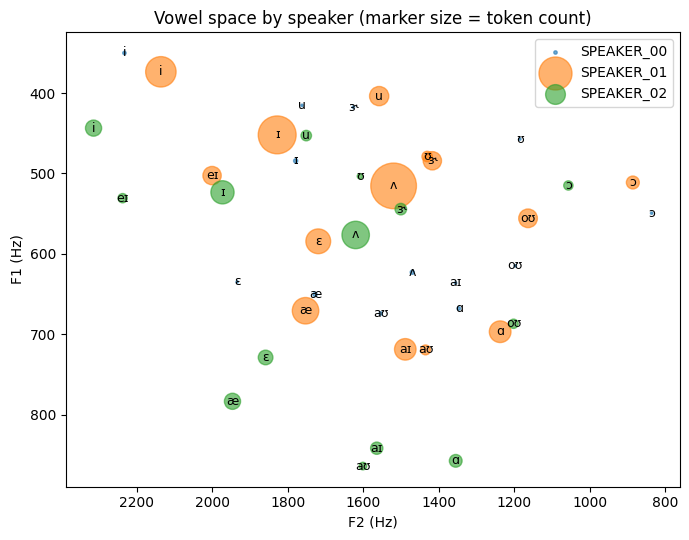

In [21]:
# Vowel space: F1 vs F2 per speaker (phonetics convention: both axes reversed)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5.5))
for spk, grp in vowels.groupby("speaker"):
    ax.scatter(grp["mean_f2"], grp["mean_f1"], s=grp["n_tokens"] * 3, alpha=.6, label=spk)
    for _, r in grp.iterrows():
        ax.annotate(r["vowel"], (r["mean_f2"], r["mean_f1"]),
                    ha="center", va="center", fontsize=9)
ax.invert_xaxis(); ax.invert_yaxis()
ax.set_xlabel("F2 (Hz)"); ax.set_ylabel("F1 (Hz)")
ax.set_title("Vowel space by speaker (marker size = token count)")
ax.legend(); plt.tight_layout(); plt.show()

Stop VOT (ms):


,speaker,phone,voicing,place,mean_vot_ms,std_vot_ms,mean_closure_ms,n_tokens,n_after_filtering
0,SPEAKER_00,d,voiced,alveolar,52.50,4.95,35.00,2,2
1,SPEAKER_00,k,voiceless,velar,5.00,0.00,50.00,1,1
2,SPEAKER_00,p,voiceless,bilabial,5.00,0.00,90.00,1,1
3,SPEAKER_00,t,voiceless,alveolar,27.00,1.41,45.00,2,2
4,SPEAKER_01,b,voiced,bilabial,44.67,52.13,69.39,87,66
5,SPEAKER_01,d,voiced,alveolar,22.57,26.26,58.89,102,72
6,SPEAKER_01,g,voiced,velar,6.92,2.75,62.31,24,13
7,SPEAKER_01,k,voiceless,velar,21.09,22.42,93.40,75,53
8,SPEAKER_01,p,voiceless,bilabial,13.12,11.20,95.76,49,33
9,SPEAKER_01,t,voiceless,alveolar,15.75,17.92,61.29,153,101


Fricative spectral moments:


,speaker,phone,voicing,place,mean_cog,std_cog,mean_spectral_sd,mean_skewness,mean_kurtosis,mean_duration_ms,n_tokens,n_after_filtering
0,SPEAKER_00,f,voiceless,labiodental,2096.1,315.0,1725.6,1.300,1.512,90.00,2,2
1,SPEAKER_00,s,voiceless,alveolar,4868.9,0.0,1248.7,-1.639,5.065,90.00,1,1
2,SPEAKER_00,z,voiced,alveolar,3152.5,1133.1,2229.3,-0.191,-0.792,130.00,2,2
3,SPEAKER_00,ð,voiced,dental,609.2,9.3,1121.5,3.459,11.965,45.00,2,2
4,SPEAKER_00,ʃ,voiceless,postalveolar,4171.1,0.0,1496.2,0.313,-0.370,60.00,1,1
5,SPEAKER_01,f,voiceless,labiodental,1532.1,617.7,1874.5,1.685,2.739,95.33,33,30
6,SPEAKER_01,s,voiceless,alveolar,4654.7,590.6,1681.5,-1.133,2.193,91.48,193,169
7,SPEAKER_01,v,voiced,labiodental,864.7,346.7,1316.0,2.966,12.243,95.00,18,16
8,SPEAKER_01,z,voiced,alveolar,3019.6,1398.8,2078.8,0.154,0.727,84.42,95,95
9,SPEAKER_01,ð,voiced,dental,701.2,176.3,1055.4,3.545,16.808,45.31,40,32


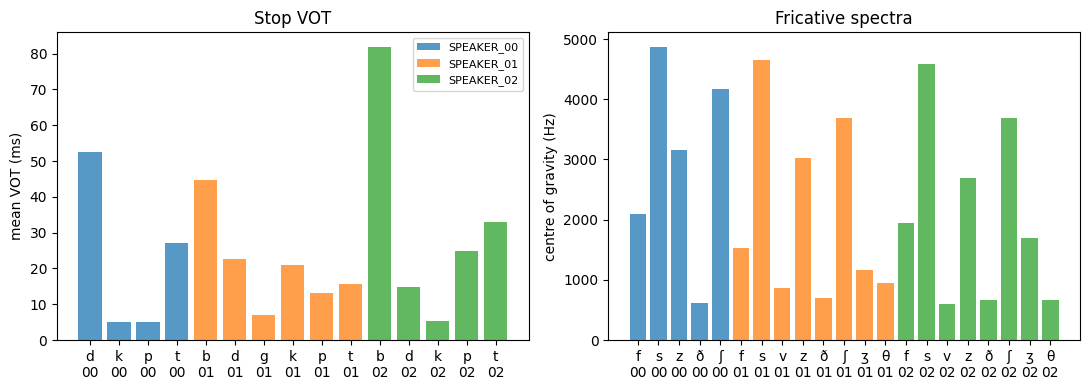

In [22]:
# Stop VOT and fricative spectra
stops = pd.read_csv(f"results/{stem}_stop_averages.csv")
frics = pd.read_csv(f"results/{stem}_fricative_averages.csv")
print("Stop VOT (ms):"); display(stops)
print("Fricative spectral moments:"); display(frics.head(10))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for spk, grp in stops.groupby("speaker"):
    axes[0].bar(grp["phone"] + f"\n{spk[-2:]}", grp["mean_vot_ms"], alpha=.75, label=spk)
axes[0].set_ylabel("mean VOT (ms)"); axes[0].set_title("Stop VOT"); axes[0].legend(fontsize=8)
for spk, grp in frics.groupby("speaker"):
    axes[1].bar(grp["phone"] + f"\n{spk[-2:]}", grp["mean_cog"], alpha=.75, label=spk)
axes[1].set_ylabel("centre of gravity (Hz)"); axes[1].set_title("Fricative spectra")
plt.tight_layout(); plt.show()

**Reading the VOT table:** English voiceless stops (/p t k/) are normally
longer than voiced (/b d g/), and in careful speech aspirated voiceless stops
run tens of milliseconds. Values clustered near zero, or no voiced/voiceless
separation, mean burst detection struggled with your recording — switch to
`vot_backend="drvot"` and re-run.

With Dr.VOT each token in `*_stop_vot.json` also carries `vot_method`
(`"drvot"` or `"tapa-fallback"`) and a `vot_type` of `POS` (aspirated) or
`NEG` (prevoiced), so you can filter on how each measurement was obtained.

## 7. Save your results

In [ ]:
!zip -qr tapa_results.zip results
from google.colab import files
files.download("tapa_results.zip")

### What is inside the download

Every file you just downloaded, previewed below, so you know the exact shape of
the data before opening it in R, Excel, or your own scripts. The CSVs hold the
**aggregated** results; the JSONs hold **every individual token** behind those
averages, which is what you want for statistics.

In [23]:
import glob, json, os
import pandas as pd
from IPython.display import display

stem = os.path.basename(sorted(glob.glob("results/*_diarization.csv"))[0]).replace("_diarization.csv", "")

print("results/ contents:")
for f in sorted(glob.glob("results/*")):
    print(f"   {os.path.basename(f):<45} {os.path.getsize(f)/1024:8.1f} KB")

results/ contents:
   OQgE0ETV81s_aligned_textgrids                      4.0 KB
   OQgE0ETV81s_diarization.csv                        0.9 KB
   OQgE0ETV81s_fricative_averages.csv                 1.7 KB
   OQgE0ETV81s_fricative_spectra.json               205.8 KB
   OQgE0ETV81s_run_summary.json                       0.8 KB
   OQgE0ETV81s_stop_averages.csv                      0.9 KB
   OQgE0ETV81s_stop_vot.json                        257.5 KB
   OQgE0ETV81s_transcription.csv                     46.2 KB
   OQgE0ETV81s_transcription.txt                      9.2 KB
   OQgE0ETV81s_vowel_averages.csv                     2.0 KB
   OQgE0ETV81s_vowel_formants.json                  359.9 KB
   sample_2min_aligned_textgrids                      4.0 KB
   sample_2min_diarization.csv                        0.4 KB
   sample_2min_fricative_averages.csv                 1.6 KB
   sample_2min_fricative_spectra.json                48.6 KB
   sample_2min_run_summary.json                       0.7 KB
   sa

In [24]:
# The aggregated tables (CSV)
for name, note in [
    ("diarization",         "who spoke when"),
    ("transcription",       "each word, with timing and speaker"),
    ("vowel_averages",      "mean F1/F2 per speaker per vowel"),
    ("stop_averages",       "mean VOT per speaker per stop"),
    ("fricative_averages",  "spectral moments per speaker per fricative"),
]:
    path = f"results/{stem}_{name}.csv"
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)
    print(f"\n=== {os.path.basename(path)} — {note}  ({len(df)} rows) ===")
    display(df.head(8))


=== OQgE0ETV81s_diarization.csv — who spoke when  (35 rows) ===


,speaker,start,end
0,SPEAKER_00,1.602,2.494
1,SPEAKER_01,2.946,5.246
2,SPEAKER_01,6.434,18.270
3,SPEAKER_01,18.850,29.630
4,SPEAKER_00,29.986,30.878
5,SPEAKER_00,31.522,32.382
6,SPEAKER_01,32.994,46.142
7,SPEAKER_02,46.722,51.646



=== OQgE0ETV81s_transcription.csv — each word, with timing and speaker  (1544 rows) ===


,speaker,word,start,end
0,SPEAKER_00,Kamala,1.62,1.98
1,SPEAKER_00,"Harris,",1.98,2.34
2,UNKNOWN,it's,2.58,3.06
3,SPEAKER_01,up,3.06,3.16
4,SPEAKER_01,good,3.16,3.30
5,SPEAKER_01,to,3.30,3.40
6,SPEAKER_01,be,3.40,3.46
7,SPEAKER_01,here.,3.46,3.58



=== OQgE0ETV81s_vowel_averages.csv — mean F1/F2 per speaker per vowel  (41 rows) ===


,speaker,vowel,mean_f1,mean_f2,std_f1,std_f2,mean_pitch,n_tokens,n_after_filtering
0,SPEAKER_00,aɪ,636.1,1355.2,0.0,0.0,130.8,1,1
1,SPEAKER_00,aʊ,674.0,1553.3,53.8,13.6,140.8,2,2
2,SPEAKER_00,i,350.2,2232.3,41.4,83.6,154.7,2,2
3,SPEAKER_00,oʊ,614.8,1196.9,0.0,0.0,142.3,1,1
4,SPEAKER_00,u,415.3,1761.7,0.0,0.0,0.0,1,1
5,SPEAKER_00,æ,650.4,1727.3,142.5,143.7,48.2,3,3
6,SPEAKER_00,ɑ,667.8,1346.6,228.7,204.9,63.0,2,2
7,SPEAKER_00,ɔ,549.3,835.7,0.0,0.0,202.8,1,1



=== OQgE0ETV81s_stop_averages.csv — mean VOT per speaker per stop  (15 rows) ===


,speaker,phone,voicing,place,mean_vot_ms,std_vot_ms,mean_closure_ms,n_tokens,n_after_filtering
0,SPEAKER_00,d,voiced,alveolar,52.50,4.95,35.00,2,2
1,SPEAKER_00,k,voiceless,velar,5.00,0.00,50.00,1,1
2,SPEAKER_00,p,voiceless,bilabial,5.00,0.00,90.00,1,1
3,SPEAKER_00,t,voiceless,alveolar,27.00,1.41,45.00,2,2
4,SPEAKER_01,b,voiced,bilabial,44.67,52.13,69.39,87,66
5,SPEAKER_01,d,voiced,alveolar,22.57,26.26,58.89,102,72
6,SPEAKER_01,g,voiced,velar,6.92,2.75,62.31,24,13
7,SPEAKER_01,k,voiceless,velar,21.09,22.42,93.40,75,53



=== OQgE0ETV81s_fricative_averages.csv — spectral moments per speaker per fricative  (21 rows) ===


,speaker,phone,voicing,place,mean_cog,std_cog,mean_spectral_sd,mean_skewness,mean_kurtosis,mean_duration_ms,n_tokens,n_after_filtering
0,SPEAKER_00,f,voiceless,labiodental,2096.1,315.0,1725.6,1.300,1.512,90.00,2,2
1,SPEAKER_00,s,voiceless,alveolar,4868.9,0.0,1248.7,-1.639,5.065,90.00,1,1
2,SPEAKER_00,z,voiced,alveolar,3152.5,1133.1,2229.3,-0.191,-0.792,130.00,2,2
3,SPEAKER_00,ð,voiced,dental,609.2,9.3,1121.5,3.459,11.965,45.00,2,2
4,SPEAKER_00,ʃ,voiceless,postalveolar,4171.1,0.0,1496.2,0.313,-0.370,60.00,1,1
5,SPEAKER_01,f,voiceless,labiodental,1532.1,617.7,1874.5,1.685,2.739,95.33,33,30
6,SPEAKER_01,s,voiceless,alveolar,4654.7,590.6,1681.5,-1.133,2.193,91.48,193,169
7,SPEAKER_01,v,voiced,labiodental,864.7,346.7,1316.0,2.966,12.243,95.00,18,16


In [32]:
# frame = pd.read_csv("results/OQgE0ETV81s_diarization.csv")
display(frame[frame['speaker']=='SPEAKER_00'])
display(frame[frame['speaker']=='SPEAKER_01'])
display(frame[frame['speaker']=='SPEAKER_02'])

,speaker,start,end
0,SPEAKER_00,1.602,2.494
4,SPEAKER_00,29.986,30.878
5,SPEAKER_00,31.522,32.382
11,SPEAKER_00,102.498,103.646
12,SPEAKER_00,104.514,105.630
30,SPEAKER_00,394.530,395.198


,speaker,start,end
1,SPEAKER_01,2.946,5.246
2,SPEAKER_01,6.434,18.270
3,SPEAKER_01,18.850,29.630
6,SPEAKER_01,32.994,46.142
10,SPEAKER_01,62.370,101.726
13,SPEAKER_01,107.010,130.750
19,SPEAKER_01,190.914,240.798
21,SPEAKER_01,244.962,279.038
22,SPEAKER_01,280.002,296.190
28,SPEAKER_01,324.834,390.622


,speaker,start,end
7,SPEAKER_02,46.722,51.646
8,SPEAKER_02,52.738,55.326
9,SPEAKER_02,56.162,61.662
14,SPEAKER_02,131.106,137.854
15,SPEAKER_02,138.594,148.318
16,SPEAKER_02,148.834,154.590
17,SPEAKER_02,155.554,172.510
18,SPEAKER_02,173.090,190.622
20,SPEAKER_02,241.218,244.286
23,SPEAKER_02,296.546,300.510


In [25]:
# The readable transcript
txt = f"results/{stem}_transcription.txt"
if os.path.exists(txt):
    print(f"=== {os.path.basename(txt)} (first 20 lines) ===\n")
    print("".join(open(txt).readlines()[:20]))

=== OQgE0ETV81s_transcription.txt (first 20 lines) ===

[SPEAKER_00] (1.6s - 2.3s)
Kamala Harris,

[UNKNOWN] (2.6s - 3.1s)
it's

[SPEAKER_01] (3.1s - 29.4s)
up good to be here. Yes, you see, have fun. Thank you. Welcome to you both. It's wonderful to have you. It's an honor to have you both here tonight. Why do you believe it's appropriate to weigh in on the racial identity of your opponent? I don't, and I don't care. I don't care what she is. I don't care. You make a big deal out of something. I couldn't care less. Whatever she wants to be is OK with me. But those were your words. So I'm asking you. I don't know. I don't know. I mean, all I can say is I read where she was

[UNKNOWN] (29.4s - 30.2s)
not

[SPEAKER_00] (30.2s - 30.5s)
black,

[UNKNOWN] (31.3s - 31.6s)
that

[SPEAKER_00] (31.6s - 32.3s)
she put out.



In [26]:
# The token-level records (JSON) — one entry per measured segment
for name, note in [
    ("vowel_formants",    "one record per vowel token"),
    ("stop_vot",          "one record per stop token"),
    ("fricative_spectra", "one record per fricative token"),
]:
    path = f"results/{stem}_{name}.json"
    if not os.path.exists(path):
        continue
    data = json.load(open(path))
    total = sum(len(toks) for per_phone in data.values() for toks in per_phone.values())
    spk = next(iter(data)); phone = next(iter(data[spk]))
    print(f"\n=== {os.path.basename(path)} — {note} ===")
    print(f"structure: {{speaker: {{phoneme: [tokens]}}}}   "
          f"speakers={list(data)}   total tokens={total}")
    print(f"example — {spk} / '{phone}', first of {len(data[spk][phone])} tokens:")
    print(json.dumps(data[spk][phone][0], indent=2))


=== OQgE0ETV81s_vowel_formants.json — one record per vowel token ===
structure: {speaker: {phoneme: [tokens]}}   speakers=['SPEAKER_00', 'SPEAKER_01', 'SPEAKER_02']   total tokens=1989
example — SPEAKER_00 / 'ʌ', first of 3 tokens:
{
  "f1": 827.3,
  "f2": 1467.1,
  "pitch": 195.6,
  "abs_start": 1.632,
  "abs_end": 1.762,
  "arpabet": "AH",
  "word": ""
}

=== OQgE0ETV81s_stop_vot.json — one record per stop token ===
structure: {speaker: {phoneme: [tokens]}}   speakers=['SPEAKER_00', 'SPEAKER_01', 'SPEAKER_02']   total tokens=653
example — SPEAKER_00 / 'k', first of 1 tokens:
{
  "vot_ms": 5.0,
  "burst_time": null,
  "voicing_onset": null,
  "closure_duration_ms": 50.0,
  "abs_start": 1.582,
  "abs_end": 1.632,
  "voicing": "voiceless",
  "place": "velar",
  "arpabet": "K",
  "following_vowel": "\u028c",
  "word": "",
  "vot_method": "drvot",
  "vot_class_drvot": "POS_VOT"
}

=== OQgE0ETV81s_fricative_spectra.json — one record per fricative token ===
structure: {speaker: {phoneme: [

In [27]:
# Turn the token-level JSON into a flat dataframe — the usual starting point
# for statistics (one row per measured token).
rows = []
for spk, per_vowel in json.load(open(f"results/{stem}_vowel_formants.json")).items():
    for vowel, tokens in per_vowel.items():
        for t in tokens:
            rows.append({"speaker": spk, "vowel": vowel, **t})
tokens_df = pd.DataFrame(rows)
print(f"{len(tokens_df)} vowel tokens, {tokens_df.shape[1]} columns")
display(tokens_df.head(10))
# e.g. tokens_df.to_csv("vowel_tokens_flat.csv", index=False)

1989 vowel tokens, 9 columns


,speaker,vowel,f1,f2,pitch,abs_start,abs_end,arpabet,word
0,SPEAKER_00,ʌ,827.3,1467.1,195.6,1.632,1.762,AH,
1,SPEAKER_00,ʌ,568.4,1540.1,0.0,1.852,1.902,AH,
2,SPEAKER_00,ʌ,472.7,1402.2,156.9,105.050,105.110,AH,
3,SPEAKER_00,ɑ,506.1,1201.7,0.0,1.792,1.822,AA,
4,SPEAKER_00,ɑ,829.5,1491.5,126.1,30.070,30.150,AA,
5,SPEAKER_00,ɛ,634.8,1933.7,159.9,1.942,2.052,EH,
6,SPEAKER_00,ɪ,438.5,1817.8,186.7,2.112,2.182,IH,
7,SPEAKER_00,ɪ,277.6,2558.3,0.0,104.560,104.590,IH,
8,SPEAKER_00,ɪ,530.1,1739.6,160.0,105.180,105.250,IH,
9,SPEAKER_00,æ,809.8,1605.2,144.5,30.326,30.506,AE,


## Where to go next

- **Longer recordings:** the pipeline streams audio at 16 kHz mono and aligns
  per segment, so memory stays flat; expect runtime to scale with duration.
- **Batch processing:** `pipeline.run_batch("audio_dir/")` processes a folder.
- **Command line:** `tapa recording.mp3 -o results/ --vot-backend drvot --drvot-repo /content/Dr.VOT`
- **All options:** see `TAPAConfig` in
  [`tapa/config.py`](https://github.com/sarmadchandio/tapa/blob/master/tapa/config.py)
  and the [README](https://github.com/sarmadchandio/tapa#readme).

If you use TAPA in published work, please cite the repository and — when using
the Dr.VOT backend — Shrem, Goldrick & Keshet (2019), *Dr.VOT: Measuring
Positive and Negative Voice Onset Time in the Wild*.